# ANN Lab 5 — Softmax Activation Function

| Field | Detail |
|---|---|
| **Name** | Muhammad Taqui |
| **Enrollment No** | 01-136221-021 |
| **Class** | BS AI (6-A) |

## Theory

The **Softmax** function converts a vector of raw scores (logits) into a probability distribution. For input vector $x$:

$$\sigma(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}$$

The outputs sum to 1, making them interpretable as class probabilities.

### Jacobian of Softmax

The derivative of softmax with respect to its inputs is a Jacobian matrix:

$$\frac{\partial \sigma_i}{\partial x_j} = \sigma_i(\delta_{ij} - \sigma_j)$$

which simplifies to $\text{diag}(\sigma) - \sigma \sigma^T$.

### Numerical Stability

Subtracting $\max(x)$ before exponentiation prevents overflow without affecting the output.

In [1]:
import numpy as np

def softmax(x: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def softmax_jacobian(x: np.ndarray) -> np.ndarray:
    """Full Jacobian matrix of softmax: diag(s) - outer(s, s)."""
    s = softmax(x)
    return np.diag(s) - np.outer(s, s)

In [2]:
x = np.array([1.0, 2.0, 3.0])

probs = softmax(x)
jacobian = softmax_jacobian(x)

print(f"Input:       {x}")
print(f"Softmax:     {probs.round(6)}")
print(f"Sum of probs: {probs.sum():.6f}  (must be 1.0)")
print(f"\nJacobian matrix:")
print(jacobian.round(6))
print(f"\nRow sums (must be ~0): {jacobian.sum(axis=1).round(10)}")

Input:       [1. 2. 3.]
Softmax:     [0.090031 0.244728 0.665241]
Sum of probs: 1.000000  (must be 1.0)

Jacobian matrix:
[[ 0.081925 -0.022033 -0.059892]
 [-0.022033  0.184836 -0.162803]
 [-0.059892 -0.162803  0.222695]]

Row sums (must be ~0): [0. 0. 0.]


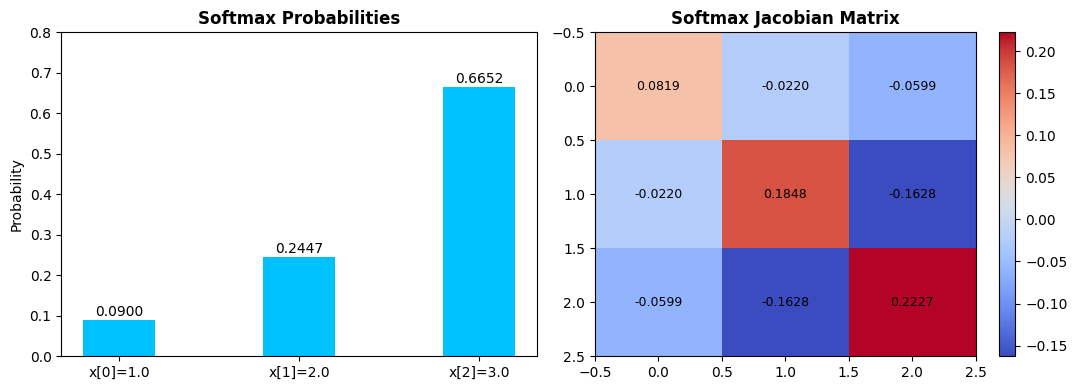

In [3]:
import matplotlib.pyplot as plt

labels = [f'x[{i}]={v}' for i, v in enumerate(x)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Probability bar chart
axes[0].bar(labels, probs, color='#00C2FF', width=0.4)
axes[0].set_ylim(0, 0.8)
axes[0].set_title('Softmax Probabilities', fontweight='bold')
axes[0].set_ylabel('Probability')
for i, p in enumerate(probs):
    axes[0].text(i, p + 0.01, f'{p:.4f}', ha='center')

# Jacobian heatmap
im = axes[1].imshow(jacobian, cmap='coolwarm', aspect='auto')
axes[1].set_title('Softmax Jacobian Matrix', fontweight='bold')
plt.colorbar(im, ax=axes[1])
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{jacobian[i, j]:.4f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion

Softmax maps arbitrary logits to a valid probability distribution. The Jacobian captures how each output probability changes with each input — essential for backpropagation in multi-class classification. Row sums equal zero, confirming the outputs always sum to a constant.

In [4]:
# iTaqiZ - PK